# Dementia Prediction using Python

___

# Introduction

Dementia is a general term that refers to a variety of conditions that cause cognitive deficits and impairments in short-term memory.

Memory loss, personality changes, anxiety, depression and behavioural changes are some of the ways it continuously affects a person with dementia.

Here, I have applied the methods of data science to predict dementia. The dataset is first cleaned and prepared for analysis using several preprocessing techniques; these include scaling continuous variables, dealing with missing values through 

# Dataset Description

The dataset comes from a mobilr healthcare program that helped elderly people in Hong Kong between 2008 and 2018. It includes information about their health and bachground to help predict dementia. There are 3,299 records with 13 variables for each person. Variables like age, Mini Nutrition Assessment totals, height, weight, waist size, and BMI are continuous. Some data, like education, Hyperlipidaemia, and mobility, are categorical variables. It also includes scores from the Mini Nutritional Assessment (MNAa_q3), which show their nutritional level. The main goal is to predict MMSE_class, which shows whether a person may have cognitive problems. This dataset can be useful for creating models that detect dementia early in older adults.

# Exploratory Data Analysis

## Importing Data

In [1]:
import pandas as pd

data = pd.read_csv(
    r"C:\\Users\\raisa\\Documents\\Dev\\Murdoch Uni\\First Semester\\ICT583 Data Science Applications\\Assignments\\Assignment 2\\ICT583 s2 2025 dataset.csv",
    sep = ",",
    header = 0
)

print(data)

        ID   Age  Education_ID  Mobility  body_height  MNAa_q3  body_weight  \
0        1  83.0           1.0       4.0        145.8      2.0        48.38   
1        2  86.0           1.0       4.0        153.2      NaN        60.81   
2        3  84.0           2.0       4.0        151.3      2.0          NaN   
3        4  84.0           2.0       4.0        140.1      2.0          NaN   
4        5  68.0           2.0       4.0        138.4      2.0        41.42   
...    ...   ...           ...       ...          ...      ...          ...   
3294  3295  90.0           1.0       4.0        144.6      2.0        56.85   
3295  3296  86.0           3.0       4.0        152.4      2.0        54.40   
3296  3297  68.0           2.0       4.0        153.5      2.0        46.21   
3297  3298  87.0           1.0       4.0        152.3      2.0        55.05   
3298  3299  72.0           2.0       4.0        156.7      2.0        65.04   

      MNAb_tot  waist    BMI  MNAa_tot  Hyperlipida

In [2]:
print(data.columns)

Index(['ID', 'Age', 'Education_ID', 'Mobility', 'body_height', 'MNAa_q3',
       'body_weight', 'MNAb_tot', 'waist', 'BMI', 'MNAa_tot',
       'Hyperlipidaemia', 'MMSE_class'],
      dtype='object')


## Summary Statistics

This dataset contains both categorical and continuous variables that describe the health and demographic status of the elderly. Categorical 

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3299 entries, 0 to 3298
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               3299 non-null   int64  
 1   Age              3185 non-null   float64
 2   Education_ID     3182 non-null   float64
 3   Mobility         3153 non-null   float64
 4   body_height      3161 non-null   float64
 5   MNAa_q3          3170 non-null   float64
 6   body_weight      3095 non-null   float64
 7   MNAb_tot         3142 non-null   float64
 8   waist            3152 non-null   float64
 9   BMI              3175 non-null   float64
 10  MNAa_tot         3181 non-null   float64
 11  Hyperlipidaemia  3192 non-null   float64
 12  MMSE_class       3299 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 335.2 KB
None


In [4]:
print(data.describe())

                ID          Age  Education_ID     Mobility  body_height  \
count  3299.000000  3185.000000   3182.000000  3153.000000  3161.000000   
mean   1650.000000    77.822292      1.866750     3.977482   153.192218   
std     952.483596    10.707237      0.675503     0.168414     9.185210   
min       1.000000    55.000000      1.000000     1.000000   130.900000   
25%     825.500000    68.000000      1.000000     4.000000   146.000000   
50%    1650.000000    79.000000      2.000000     4.000000   151.000000   
75%    2474.500000    87.000000      2.000000     4.000000   161.000000   
max    3299.000000   104.000000      4.000000     4.000000   184.000000   

           MNAa_q3  body_weight     MNAb_tot        waist          BMI  \
count  3170.000000  3095.000000  3142.000000  3152.000000  3175.000000   
mean      1.992744    56.210918    11.897040    85.424365    23.572781   
std       0.101788    11.356684     1.507597    10.569643     4.174077   
min       0.000000    30.200

In [5]:
categorical = [
    "Hyperlipidaemia",
    "Mobility",
    "Education_ID",
    "MNAa_q3",
    "MMSE_class"
]

continuous = [
    "Age",
    "body_height",
    "body_weight",
    "MNAa_tot",
    "MNAb_tot",
    "waist",
    "BMI"
]

### Categorical Data Mapping

In [6]:
categorical_tables = {
    col: data[col].value_counts(dropna=False)
    for col in categorical
}

categorical_tables

{'Hyperlipidaemia': Hyperlipidaemia
 0.0    3045
 1.0     147
 NaN     107
 Name: count, dtype: int64,
 'Mobility': Mobility
 4.0    3089
 NaN     146
 3.0      60
 1.0       3
 2.0       1
 Name: count, dtype: int64,
 'Education_ID': Education_ID
 2.0    1740
 1.0     944
 3.0     476
 NaN     117
 4.0      22
 Name: count, dtype: int64,
 'MNAa_q3': MNAa_q3
 2.0    3152
 NaN     129
 1.0      13
 0.0       5
 Name: count, dtype: int64,
 'MMSE_class': MMSE_class
 0    2740
 1     559
 Name: count, dtype: int64}

### Mean and Standard Deviation for continuous  variables

In [7]:
# import pandas as pd

continuous_stats = pd.DataFrame({
    col: {
        "Mean": round(data[col].mean(skipna=True), 2),
        "SD": round(data[col].std(skipna=True), 2)
    }
    for col in continuous
}).T

continuous_stats

,Mean,SD
Age,77.82,10.71
body_height,153.19,9.19
body_weight,56.21,11.36
MNAa_tot,13.04,1.33
MNAb_tot,11.90,1.51
waist,85.42,10.57
BMI,23.57,4.17


<!-- # Variable Correlation

To see the relationship between variables in this dataset, a correlation analysis was done. Given that the Shapiro-Wilk test indicated most numeric variables are not normally distributed, I used Spearman's correlation as a non-parametric way to measure monotic relationships between variables. The results show the strength and direction of associations: positive values indicate that when one variable increases, the other tends to increase, while negative values imply the opposite. -->

## Correlation

### Shapiro-Wilk Test For Normality

The Shapiro-Wilk test is a statistical test on normality. It's very important to check for normality before applying methods such as the t-test, which require that the data be normally distributed. Under this approach, we test the null hypothesis that the data is drawn from a normal distributions. If the test fails to reject this hypothesis that the data is approximately normal, and the data analyst can safely apply a parametric test like a t-test. Conversely, if normality is rejected, then one would want to apply a non-parametric alternative test, such as the sign test. In this project, I conducted a Shapiro-Wilk test for the variables to verify their normality before proceeding with further statistical analysis.

In [8]:
from scipy.stats import shapiro

# Select numeric variables
numeric_vars = data.select_dtypes(include="number")

# Apply Shapiro-Wilk test to each numeric variable
shapiro_results = {}

for col in numeric_vars.columns:
    x = numeric_vars[col].dropna()

    # Skip constant or very short variables
    if x.nunique() < 3:
        shapiro_results[col] = None
    else:
        stat, p_value = shapiro(x)
        shapiro_results[col] = p_value

# Convert to Series for clean display
shapiro_results = pd.Series(shapiro_results)

shapiro_results

ID                 8.651470e-31
Age                4.570843e-31
Education_ID       1.831373e-52
Mobility           2.996473e-81
body_height        8.972634e-30
MNAa_q3            5.463270e-83
body_weight        9.553224e-20
MNAb_tot           6.156958e-38
waist              1.236353e-10
BMI                1.201484e-12
MNAa_tot           2.495446e-57
Hyperlipidaemia             NaN
MMSE_class                  NaN
dtype: float64

**Null hypothesis (H₀):**
The data comes from a normally distributed population.

**Decision rule:**
- p > 0.05 -> fail to reject H₀ -> approximately normal
- p ≤ 0.05 -> reject H₀ -> not normal

The output represents that these p-values are extremely small (close to 0). They are < 0.05.
These variables are *not normally distributed*.

**Histogram Visualization**

C:\Users\raisa\AppData\Local\Temp\ipykernel_5920\1212718163.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect = [0,0,1,-.96])


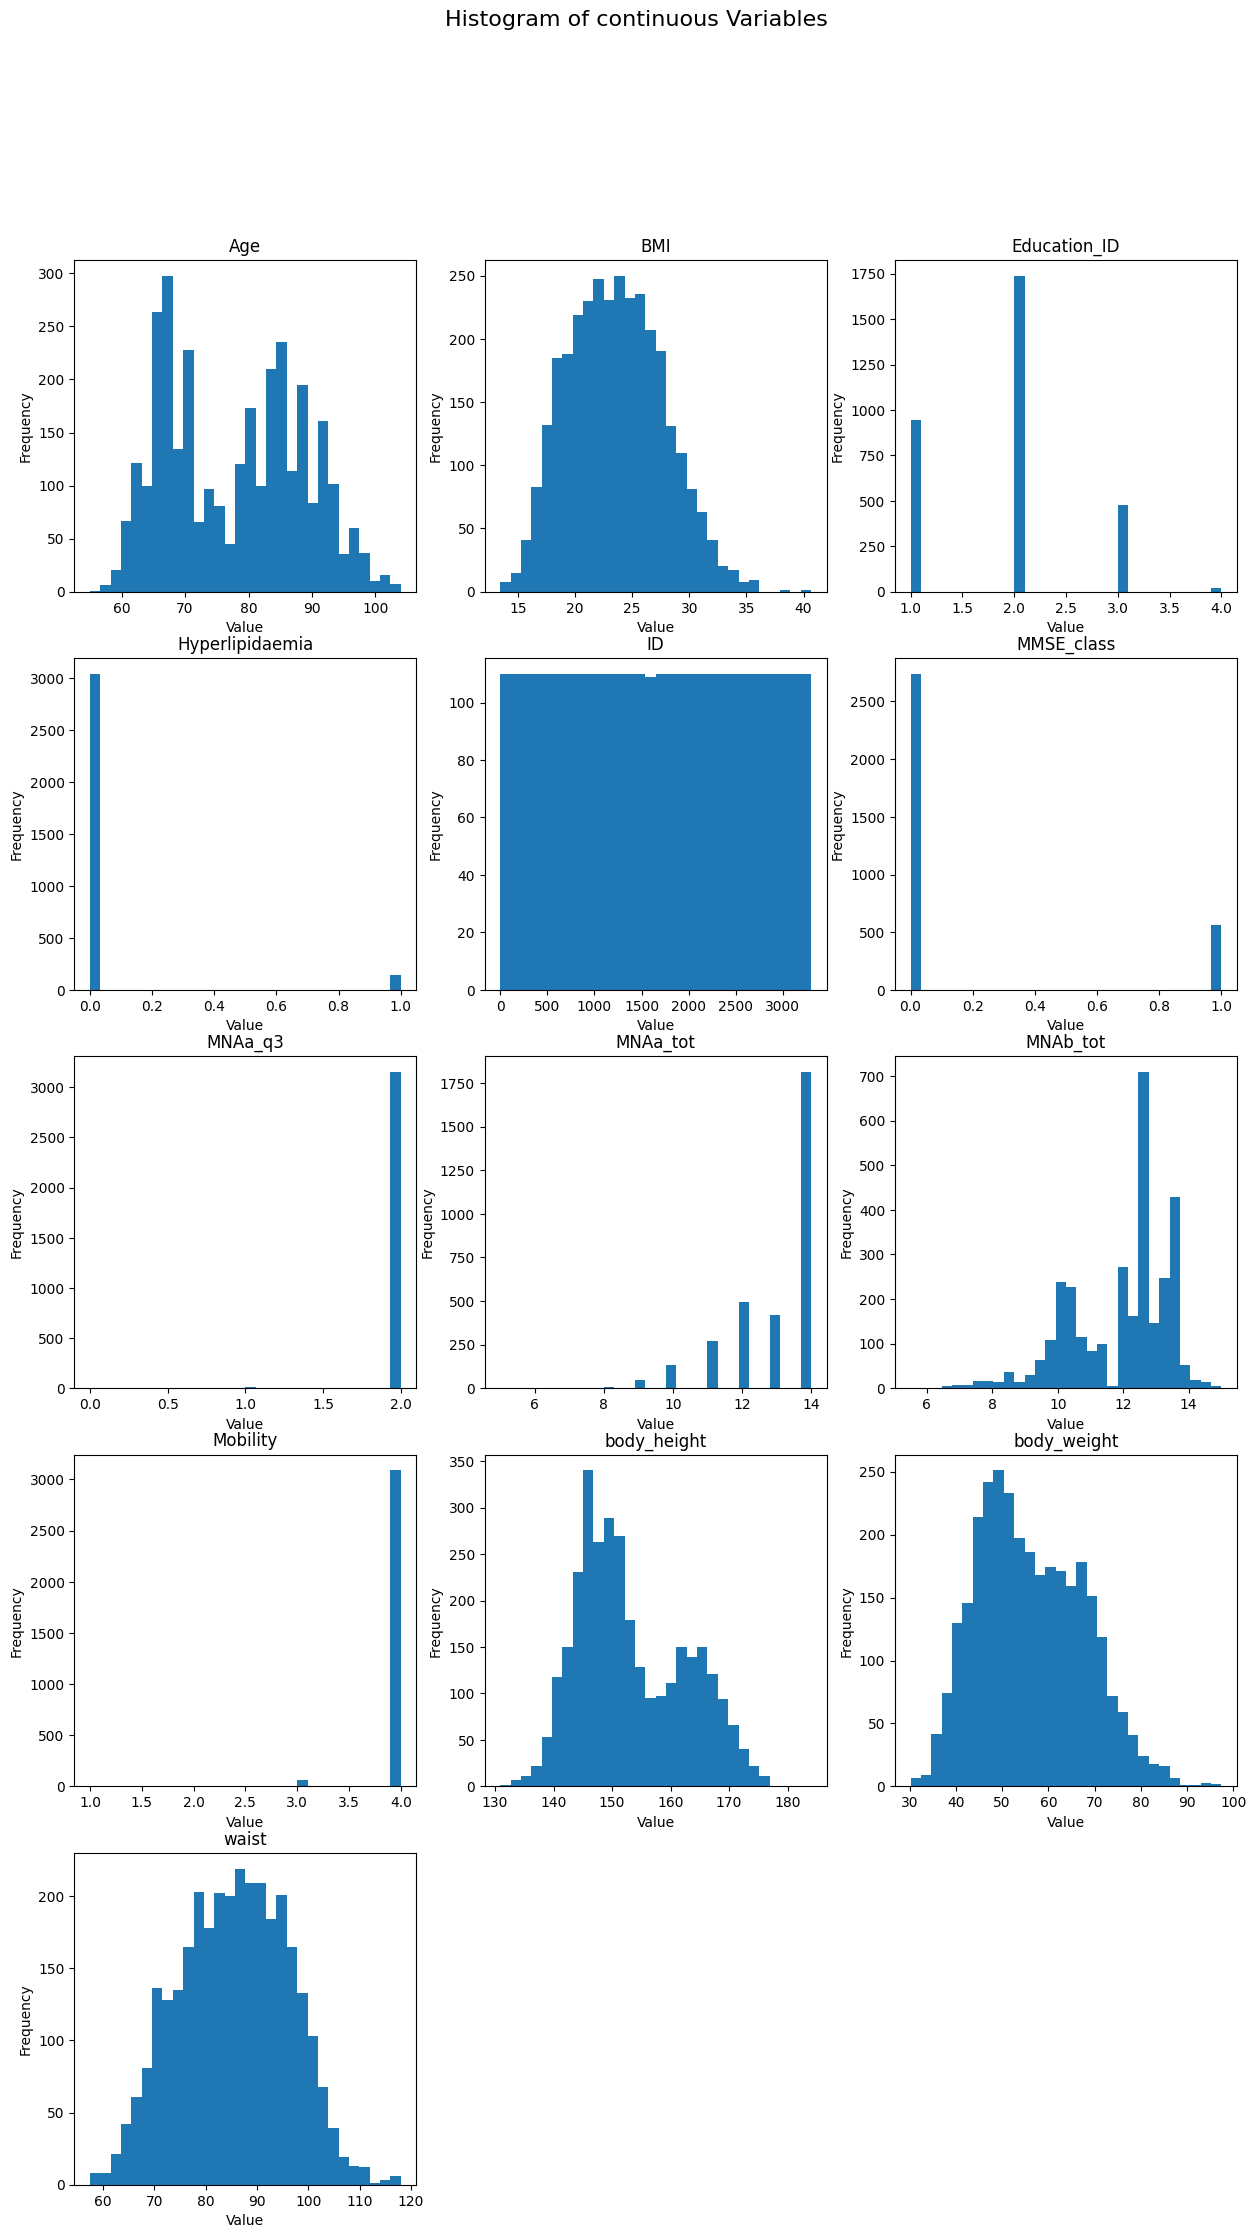

In [9]:
import matplotlib.pyplot as plt
import math

# Reshape data: equivalent to gather()
long_data = numeric_vars.melt(
    var_name = "variable",
    value_name = "value"
)

# Drop missing values
long_data = long_data.dropna()

# Determine grid size
n_vars = long_data["variable"].nunique()
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# Plot histogram for each variable
for ax, (var, subset) in zip(axes, long_data.groupby("variable")):
    ax.hist(subset["value"], bins = 30)
    ax.set_title(var)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Remove unused axes
for i in range(len(long_data["variable"].unique()), len(axes)):
    fig.delaxes(axes[i])

# Overall title
fig.suptitle("Histogram of continuous Variables", fontsize = 16)
plt.tight_layout(rect = [0,0,1,-.96])

plt.show()

### Spearman Correlation

Since, the variable are not normally distributed, we use Spearman correlation.

In [10]:
# Select numeric variables 
numeric_data = data.select_dtypes(include="number")

# Compute Spearman correlation using pairwise complete observations
corr = numeric_data.corr(
    method="spearman",
    min_periods=1
).round(3)

# Display correlation matrix
corr

,ID,Age,Education_ID,Mobility,body_height,MNAa_q3,body_weight,MNAb_tot,waist,BMI,MNAa_tot,Hyperlipidaemia,MMSE_class
ID,1.000,-0.011,0.000,0.024,0.002,-0.004,0.011,-0.000,-0.001,0.011,-0.010,-0.009,0.011
Age,-0.011,1.000,-0.634,-0.153,-0.522,-0.086,-0.190,-0.538,0.052,-0.020,-0.235,0.037,0.487
Education_ID,0.000,-0.634,1.000,0.090,0.535,-0.008,0.102,0.441,-0.123,-0.093,0.055,0.028,-0.549
Mobility,0.024,-0.153,0.090,1.000,0.055,0.306,-0.016,0.054,-0.094,-0.062,0.059,-0.102,-0.146
body_height,0.002,-0.522,0.535,0.055,1.000,0.011,0.456,0.554,0.223,0.234,0.293,0.008,-0.348
MNAa_q3,-0.004,-0.086,-0.008,0.306,0.011,1.000,-0.001,0.062,-0.025,-0.010,0.115,-0.024,-0.146
body_weight,0.011,-0.190,0.102,-0.016,0.456,-0.001,1.000,0.498,0.764,0.796,0.720,0.054,-0.119
MNAb_tot,-0.000,-0.538,0.441,0.054,0.554,0.062,0.498,1.000,0.320,0.386,0.536,0.056,-0.404
waist,-0.001,0.052,-0.123,-0.094,0.223,-0.025,0.764,0.320,1.000,0.800,0.642,0.074,0.056
BMI,0.011,-0.020,-0.093,-0.062,0.234,-0.010,0.796,0.386,0.800,1.000,0.724,0.077,0.013


**How to interpret the Correlation Matrix?**

Spearman correlation values range from:
- +1 -> string postive monotonic relationship
- 0 -> no monotonic relationship
- -1 -> strong negative monotonic relationship

Rule of thumb (for reports):

| | Strength |
|--|-------|
|0.00-0.19|Very weak|
|0.20-0.39|Weak|
|0.40-0.59|Moderate|
|0.60-0.79|Strong|
|0.80-1.00|Very Strong|

**Correlation Heatmap**

Let's create a correlation heatmap for a better understanding of the correlation matrix.

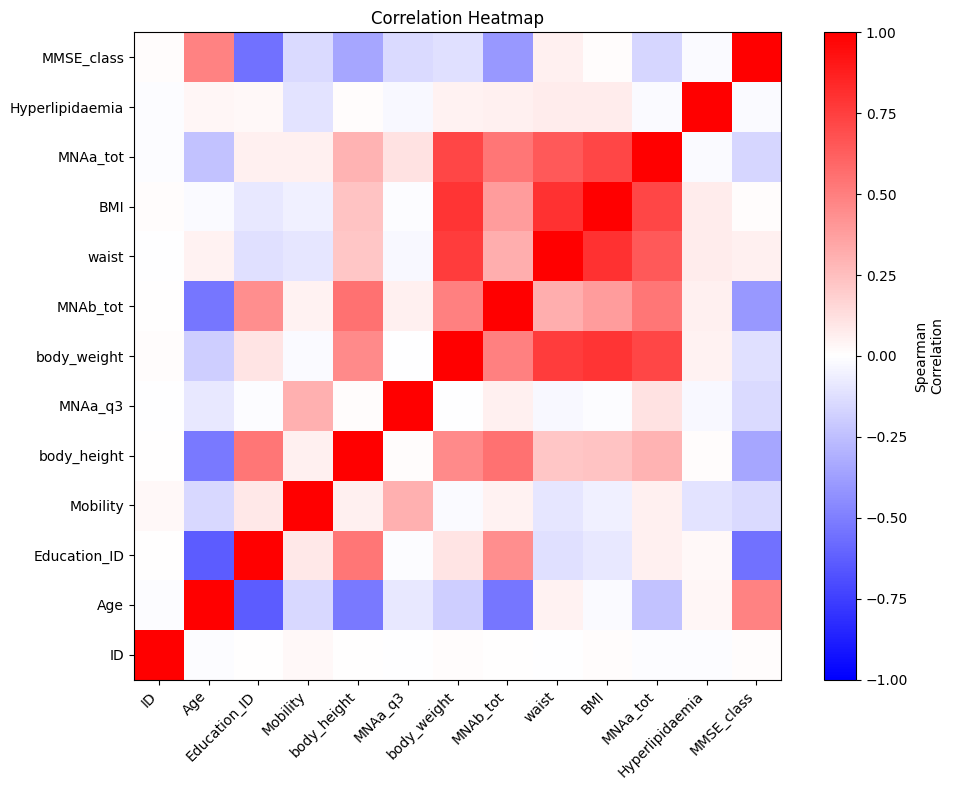

In [11]:
import numpy as np

# Convert correlation matrix to numpy array
corr_values = corr.values
labels = corr.columns

# Create figure
plt.figure(figsize=(10,8))

# Plot heatmap
im = plt.imshow(
    corr_values,
    cmap="bwr", # blue white read
    vmin=-1, vmax=1,
    origin="lower"
)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label("Spearman\nCorrelation")

# Set axis ticks and labels
plt.xticks(
    ticks=np.arange(len(labels)),
    labels=labels,
    rotation=45,
    ha="right",
    fontsize=10
)

plt.yticks(
    ticks=np.arange(len(labels)),
    labels=labels,
    fontsize=10
)

# Fix aspect ratio
plt.gca().set_aspect("equal")

# Titles and labels
plt.title("Correlation Heatmap")
plt.xlabel("")
plt.ylabel("")

# Minimal theme-like cleanup
plt.tight_layout()

# Save figure
# plt.savefig("correlation.png", dpi=300)
plt.show()

# Data Preprocessing

## Data Imputation

During the preprocessing of the data, I checked for the presence of missing values across all variables. Then, I according to the correlation between the variables, I decided to apply a imputation method to fill the missing data.

### 1. Find missing data

In [12]:
missing_counts = data.isna().sum()
missing_counts

ID                   0
Age                114
Education_ID       117
Mobility           146
body_height        138
MNAa_q3            129
body_weight        204
MNAb_tot           157
waist              147
BMI                124
MNAa_tot           118
Hyperlipidaemia    107
MMSE_class           0
dtype: int64

### 2. Imputation using Hot-deck

Hot-deck imputation is a good fit for this dataset because it replaces missing values iwth actual responses from similar cases, which can help retain natural variability and the plausibility of the data without assuming complex statistical methods.

In [13]:
data_1 = data.copy()

match_vars = ["Education_ID", "Mobility", "MNAa_q3", "MMSE_class"]

for idx, row in data_1[data_1["Age"].isna()].iterrows():
    donors = data_1[
        (data_1["Age"].notna())
    ]

    for var in match_vars:
        filtered = donors[donors[var] == row[var]]
        if len(filtered) > 0:
            donors = filtered

    if len(donors) > 0:
        data_1.at[idx, "Age"] = donors["Age"].sample(1).values[0]

In [14]:
# Verifying the imputation
data["Age"].isna().sum(), data_1["Age"].isna().sum()

(np.int64(114), np.int64(0))

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a copy
plot_data = data_1.copy()

# Flag which Age values were imputed
plot_data["Age_imp"] = data["Age"].isna().map(
    {True: "Imputed", False: "Observed"}
)


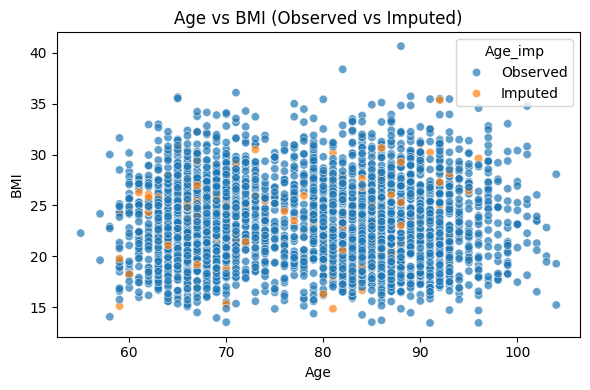

In [16]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=plot_data,
    x="Age",
    y="BMI",
    hue="Age_imp",
    alpha=0.7
)

plt.title("Age vs BMI (Observed vs Imputed)")
plt.tight_layout()
plt.show()


To visualize the imputation results, margin plots were created for key variables related to cognitive function (MMSE_class), including Age, Education_ID, body_height and MNAb_tot. These plots show the distribution of original and imputed values, confirming that the hot deck imputation maintained realistic data patterns.

In [17]:
data_2 = data_1.copy()

match_vars_2 = ["Age"]

for idx, row in data_2[data_2["body_height"].isna()].iterrows():
    donors = data_2[data_2["body_height"].notna()]

    for var in match_vars_2:
        donors = donors[donors[var] == row[var]]

    if len(donors) > 0:
        data_2.at[idx, "body_height"] = donors["body_height"].sample(1).values[0]

In [18]:
# Verifying

data["body_height"].isna().sum(), data_2["body_height"].isna().sum()

(np.int64(138), np.int64(0))

In [19]:
plot_data_2 = data_2.copy()

plot_data_2["body_height_imp"] = data["Age"].isna().map(
    {True: "Imputed", False: "Observed"}
)

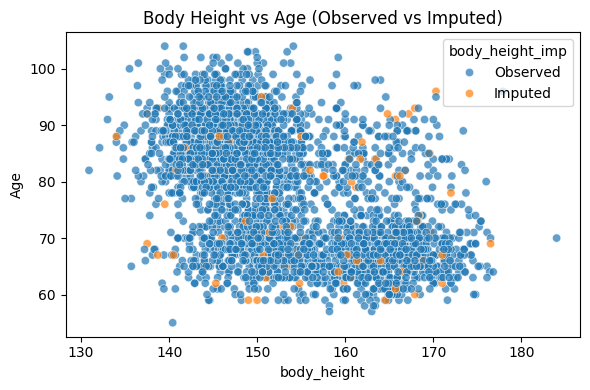

In [20]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=plot_data_2,
    x="body_height",
    y="Age",
    hue="body_height_imp",
    alpha=0.7
)

plt.title("Body Height vs Age (Observed vs Imputed)")
plt.tight_layout()
plt.show()

___

In [ ]:
# MNAb_tot imputation
data_3 = data_2.copy()

match_vars_3 = []

NameError: name 'data_2' is not defined